In [17]:
%load_ext autoreload
%autoreload 2

import torchvision as tv
tform = tv.models.ResNet50_Weights.IMAGENET1K_V1.transforms()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from model_loader import resnet50pt

resnet50pt()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/santripta/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 64.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
import yaml

with open("inference_runs_imagenet/pretrained.yaml", 'r') as f:
    config = yaml.safe_load(f)

config

{'datasets': {'imagenetpt': '/media/solis/DATA/imagenet'},
 'epochs': {'imagenetpt': ['all']},
 'collect': {'resnet50pt': [{'path': 'fc', 'tag': 1}]},
 'runs': {'resnet50pt_imagenetsb': {'model': 'resnet50pt',
   'dataset': 'imagenetpt'}},
 'do': ['resnet50pt_imagenetsb'],
 'checkpoints_dir': None,
 'save_dir': '/media/santripta/data2/Inference_imagenet/landscape_data_cross_epoch/',
 'device': 'cuda:0'}

In [53]:
from imagenet_loader import ImageNetDataset, make_imagenet_dataloaders

train_ds = ImageNetDataset('/media/solis/DATA/imagenet', split='train', transform=tform, permute=True)
test_ds = ImageNetDataset('/media/solis/DATA/imagenet', split='val', transform=tform, permute=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Text(0.5, 1.0, "Label: 953, Classname: ('pineapple', 'ananas')")

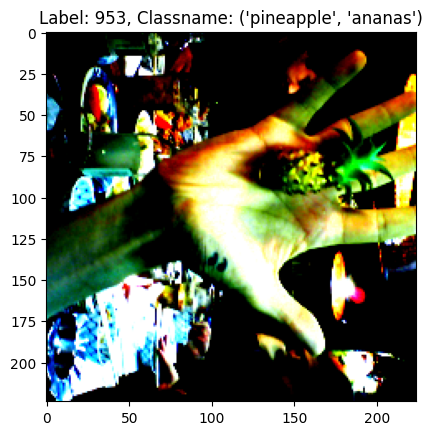

In [56]:
import matplotlib.pyplot as plt

sample = train_ds[0]
img = sample['image']
label = sample['label']
classname = sample['classname']

plt.imshow(img.permute(1, 2, 0))
plt.title(f'Label: {label}, Classname: {classname}')

In [52]:
test_loader, val_loader = make_imagenet_dataloaders(
    data_dir='/media/solis/DATA/imagenet',
    batch_size=32,
    transform=tform,
    random_label_prop=0.0,
    num_workers=4,
)

TypeError: make_imagenet_dataloaders() got an unexpected keyword argument 'data_dir'

In [58]:
import pandas as pd
df = pd.read_csv("/media/santripta/data2/Inference_imagenet/landscape_data_pt/resnet50pt_imagenetsb/compiled_results.csv")

In [64]:
df["Original_Label"].value_counts().to_csv("imagenet_label_distribution.csv")

In [65]:
df["Predicted_Label"].value_counts().to_csv("imagenet_predicted_label_distribution.csv")